<a href="https://colab.research.google.com/github/mauracarter-statistics/csc162/blob/main/carter_maura_162_mod2_mnist_return.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Maura Carter**
Module 2, MNIST Data;
CSC 162, Fall 2025;
November 12, 2025


**DUE: Monday, NOV. 17, 2025**

**INSTRUCTIONS:**

**Overview**

*In this assignment, you will:*

1. Load and preprocess the EMNIST Letters dataset (a handwritten alphabet dataset).

2. Build a Convolutional Neural Network (CNN) using TensorFlow and Keras.

3. Train and evaluate your model on the dataset.

4. Visualize some predictions from the test set.

CNNs are effective in image processing and classification tasks because they automatically learn hierarchical features from raw pixel data. In this task, you will practice using layers such as convolution, pooling, and activation functions to extract meaningful patterns from handwritten letters.

1. If needed, review the following lecture:

2. Video - Introduction to CNNs Using Google Colab Lecture: https://youtu.be/7L0FXpE6Vns

**TASK INSTRUCTIONS:**

**1. Data Loading and Preprocessing**
Objective: Load the EMNIST Letters dataset using TensorFlow Datasets and preprocess the images.



**Objective:** Load the EMNIST Letters dataset using TensorFlow Datasets and preprocess the images.

**Requirements:**

1. Normalize pixel values so that they are between 0 and 1.

2. Reshape images to include a channel dimension (28×28×1) for grayscale.

3. Split the dataset into training and testing sets.

**Starter Code for Loading EMNIST Data:**

**Import packages.**

In [47]:
#python
# Import necessary packages
import tensorflow as tf
from tensorflow.keras import datasets, layers, models #make sure to include "models" because that is used later in the code, when building a sequential cnn
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

**Load the EMNIST dataset.**

In [48]:
# Load the EMNIST Letters dataset.
# This dataset contains 145,600 training images and 14,400 testing images (grayscale, 28x28) (this is how many is supposed to be in the set, but later when I counted the number in the test and train sets my numbers were slightly different).
(ds_train, ds_test), ds_info = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,  # returns tuple (img, label)   #the practice dataset from the lecture had number digits, and it had two components for both train and test (x_train, y_train) and (x_test, y_test) because it was a separate image and a separate label (and we needed both objects). But in this case, each image is a tuple that has an image and a label.
    with_info=True
)


**Preprocess the images.**

In [49]:
# Function to preprocess the images
def preprocess(image, label):
    # Convert image dtype to float32 and scale pixels to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    # Reshape image to (28, 28, 1) for CNN input; in this case we need to reshape to (28, 28, 1) to use batch size of 64 later (instead of the default batch size 32)
    image = tf.expand_dims(image, -1)
    # Adjust label: EMNIST Letters dataset labels are in the range [1, 26]; subtract 1 to get [0, 25]
    label = label - 1
    return image, label

**Apply the preprocessing function** (to the train and test datasets).

In [50]:
# Apply the preprocessing function to the train and test datasets.
ds_train = ds_train.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

**Batch and prefetch the datasets** (for training efficiency).

The batch size matters because when I run the model later, the steps_per_epoch = total_number_in_sample / batch_size. The batch size is needed to know how many steps to run in each epoch. I changed the batch size to 32 and tried to run the model, but it didn't work because it said that batch size 32 didn't match the image shape (28, 28, 1), so I changed it back to 64.

In [51]:
# Batch and prefetch the datasets for training efficiency.
batch_size = 64
ds_train = ds_train.cache().shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

**2. Build the CNN Model**
Objective: Create a CNN using TensorFlow Keras.

**Objective:** Create a CNN using TensorFlow Keras.

**Requirements:**

1. Use at least two Conv2D layers with appropriate filter sizes (e.g., 32 and 64 filters) and a kernel size (commonly 3×3).

2. Include MaxPooling2D layers following each convolution to reduce feature map dimensions.

3. Add activation functions (e.g., ReLU) after convolution layers.

4. Flatten feature maps and add one or more Dense (fully connected) layers.

5. Use a final Dense layer with softmax activation to output predictions over 26 classes (representing A–Z).


In [52]:
# Build a Sequential CNN model for Full MNIST letters dataset.

#this is where we add the layers to the convolutional neural network. It had multiple convolutional layers which apply filters that do things like extract features (like edges, corners, certain textures).
#pooling layers are added to our model to reduce the spatial dimensions of feature maps. One purpose of this is to decrease the number of parameters which can reduce computation or perhaps overfitting.
#other layers, such as dense layers, are included because they do classification (in this case, classification is classifying each image into a category of letter; for example, it would classify a letter as an "A" of a "C", etc.); it does the classification by interpreting the high-level features (these are the features that got extracted by the convolutional layers and sometimes pooling layers).

full_mnist_model = models.Sequential([
    #Convolutional layer: Applies 32 filters of size 3x3 using ReLU activation.
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)), #filter size is 3x3

    #Max pooling layer: Reduces spatial dimensions by taking the max value in 2x2 windows.
    layers.MaxPooling2D((2, 2)),   #filter size is 2x2

    #Second convolutional layer: Uses 64 filters to extract more complex features.
    layers.Conv2D(64, (3, 3), activation='relu'),   #use activation functions inside the convolutional layers, in this case define the activation function as Relu.
                                                   #filter size is 3x3
    #Second max pooling layer.
    layers.MaxPooling2D((2, 2)),  #filter dize is 2x2

    #Flatten the feature maps into a 1D vector.
    layers.Flatten(),   #must have a flattening layer and this is the only flattening layer in this model

    #Dense layer: Learns a complex representation from features.
    layers.Dense(64, activation='relu'), #use activation functions inside the convolutional layers, in this case define the activation function as Relu.

    #Output layer: Produces 26 class probabilities via softmax activation.
    layers.Dense(26, activation='softmax') #make sure to define the number of classes produced as 26,since there are 26 letters in the alphabet; (and not 10 as in the practice mnist digits dataset from the lecture; in that example, we used 10 since the digits 1-9 and 0 make 10) because there are more letters (and thus classes) than digits from the other dataset.
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**3. Model Compilation and Training**

**Steps:**

1. Compile the model using the Adam optimizer and the sparse categorical cross-entropy loss (since labels are integers in the range [0, 25]).

2. Train your model for about 10–20 epochs.

3. Use part of the training data for validation (e.g., set validation_split if using non-dataset pipeline or create a separate validation set).

1. Compile the model

In [53]:
#Compile the model with the Adam optimizer and sparse categorical cross-entropy loss
full_mnist_model.compile(optimizer='adam',                    #a model must be compiled before it is trained and before model.fit (running the model). Adam is the optimization algorithm and it applies the weights.
                      loss='sparse_categorical_crossentropy',   #we defined how the loss is calculated to be a method called 'sparce_categorical_crossentropy" since that is what method was used in the video lecture, but there are other methods, depending on the type of model and data
                      metrics=['accuracy'])       #here we are defining the metric to be accuracy, but could possibly be F1 Score, Confusion Matrix, etc. if we wanted (but I chose Accuracy).



2. Validation (using part of the training data).

Due to the type of data structure, the validation split had to be done on the training data prior to running the model.fit, whereas on the mnist digits data, the validation split was a set as a paramenter when running the model.fit because it had a different data structure.

Here, the intial training data is split into train_size and validation_size, which basically means I split the entire traning data into two parts, with 90% of the original training data staying as training data, and 10% of the original training data becoming data used for validation.

In [54]:
#Python
#First, split the data into train and validation before the doing the model fit step (using 10% of data as validation).
TRAIN_SIZE = int(0.9 * ds_info.splits['train'].num_examples) # 90% for training
VALIDATION_SIZE = ds_info.splits['train'].num_examples - TRAIN_SIZE # 10% for validation

ds_train_subset = ds_train.take(TRAIN_SIZE) #.repeat()
ds_validation_subset = ds_train.skip(TRAIN_SIZE).take(VALIDATION_SIZE)

3. TRAIN THE MODEL (10-20 epochs).

Count the number of data images in the training data total, the training only, and the validation.

In [55]:
#TOTAL NUMBER TRAINING SAMPLES (prior to splitting off part of validation)
ds_info.splits['train'].num_examples    # 88,800 is the total number of images (BEFORE splitting of part of the training set for validation)

#Training set size - Print the size
print(f"Training set size: {TRAIN_SIZE}") #training set size: 79,920

#Validation set size - Print the size
print(f"Validation set size: {VALIDATION_SIZE}") #validation set size: 8,880

#BATCH SIZE
#batch_size =    #if you are using data generators or tf.data.Dataset objects (which already generate batches), you should not specify the batch size
#in model.fit(), as the batch size is determined by how the dataset or generator was configured.
#default batch size is 32 (in keras), but earlier in the code we opted to set batch size = 64.

#STEPS PER EPOCH
#steps_per_epoch = total_number_of_training_samples / batch_size
steps_per_epoch = 88880 / 64
print(f"Steps per epoch: {steps_per_epoch}") #steps per epoch: 1388.75. The computer (without me specifiying the steps_per_epoch inside the model) was alreaady using 1388, so I got basically the same number of steps_per_epoch.



Training set size: 79920
Validation set size: 8880
Steps per epoch: 1388.75


(Train the model). **Choose the number of epochs.** Sometimes the accurcies of the epochs, and the model, have less variation (when you run the model more than once) if you have a larger number of epochs; less variation in the accuracies is a good thing; However you can also overfit the model if you do too many epochs. So you have to figure out what an appropriate number of epochs is to get the best and most consistent accuracies when rerunning the model, but also not overfit the model.

In [58]:
#Train the full MNIST model for 10 epochs (using 10% of data as validation); pass the validation subset in to the model "fit" using the validation_data instead of validation_split (because I already split the data prior to the "fit" command in the model.)
#full_mnist_model.fit(ds_train, epochs=10, validation_split=0.1) #not using this one - this was from the practice during the lecture using mnist digits data.

#first use epochs = 10, then try a different number such as epochs = 16.
full_mnist_model.fit(ds_train_subset, epochs=12, validation_data=ds_validation_subset)
#full_mnist_model.fit(ds_train_subset, epochs=12, steps_per_epoch = 1388, validation_data=ds_validation_subset) #don't need to specify the steps_per_epoch because I would specify the same number that the model was alread doing without me specifying it.

Epoch 1/12
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 75s 54ms/step - accuracy: 0.9278 - loss: 0.2145
Epoch 2/12
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 87s 58ms/step - accuracy: 0.9350 - loss: 0.1876
Epoch 3/12
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 73s 52ms/step - accuracy: 0.9412 - loss: 0.1676
Epoch 4/12
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 80s 58ms/step - accuracy: 0.9454 - loss: 0.1518
Epoch 5/12
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 85s 61ms/step - accuracy: 0.9508 - loss: 0.1354
Epoch 6/12
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 85s 61ms/step - accuracy: 0.9545 - loss: 0.1237
Epoch 7/12
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 70s 51ms/step - accuracy: 0.9576 - loss: 0.1120
Epoch 8/12
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 76s 47ms/step - accuracy: 0.9594 - loss: 0.1049
Epoch 9/12
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 65s 47ms/step - accuracy: 0.9627 - loss: 0.0961
Epoch 10/12
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 78s 56ms/step - accuracy: 0.9639 - loss: 0.0909
Epoch 11/12
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 65s 47ms/step - accuracy: 0.9660 - loss: 0.0839
Epoch 12

Below is a screen shot of the epochs output when the model was doing 10 epochs, the first time I ran the model.

You can see that each epoch gradually increased in accuracy, with the first epoch having smallest accuracy (but in this case, still pretty high!) of all the epochs, and the last epoch having the highest accuracy. This isn't necessarily always the case (with the gradual increase between epochs....sometimes when running this model, due to randomness, the increases could be steeper or less steep).

Here, the first time I ran the model with 10 epochs, **the range of accuracies for the epochs was from 96.25% to 97.48%.**


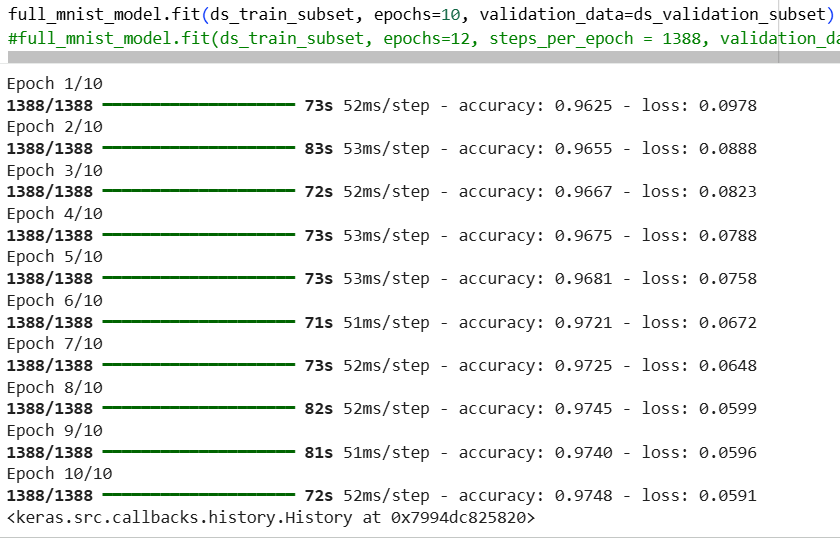

I noticed when I reran the model a second time with 10 epochs, the accuracy was different. I ran it another of times and came up with different accuracies.

I researched this and found out that optimization algorithms, including adam, have a "stochastic nature" which also means they include randomness. Many of these models update the model weights based on what are called "mini-batches" of the data which are data that are randomly sampled from the training set. Because they are randomly sampled, they are likely to be different each time the model is run. When something has a "stochastic element" it means that the exact sequence of the weight updates is not the same and it can be different between runs. These differences help account for the variation in the final models when the models are run a number of times.

I also saw the there are ways to reduce the variation in accuracies when running the model more than once, and some of those methods include larger datasets, increasing the number of epochs, and setting a seed (for the libraries used, such as NumPy and TensorFlow) which helps create reproducibility of the weight initialization (similar weights, which helps the model reduce the amount of randomness which in turn reduces the variation in the model accuracy each time you run the model).



Below, is the screenshot of the output from running the model a second time, with 10 epochs. The accuracies are different for the epochs. Here, **the accuracies for the epochs range from 77.89% to 95.73%**.

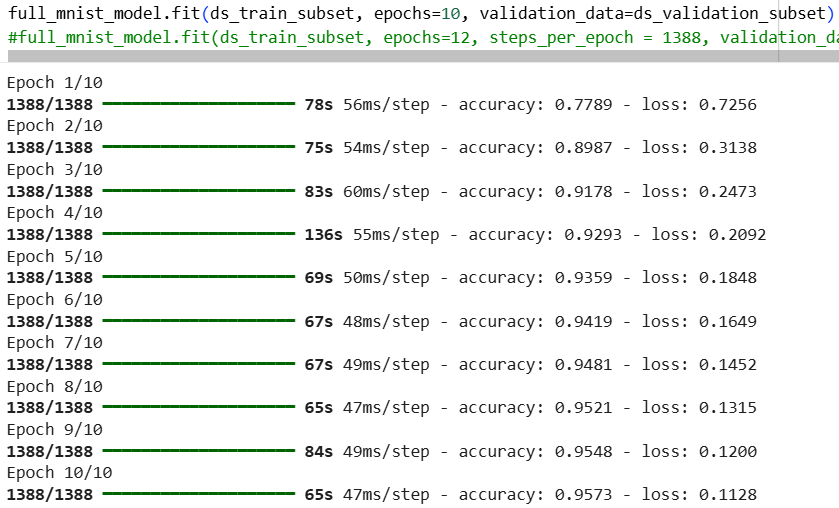

I ran the model a third time, but this time I changed the number of epochs to **12 epochs**. The screen shot below shows the results. The **epoch accuracies ranged from 92.78% to 96.69%**.

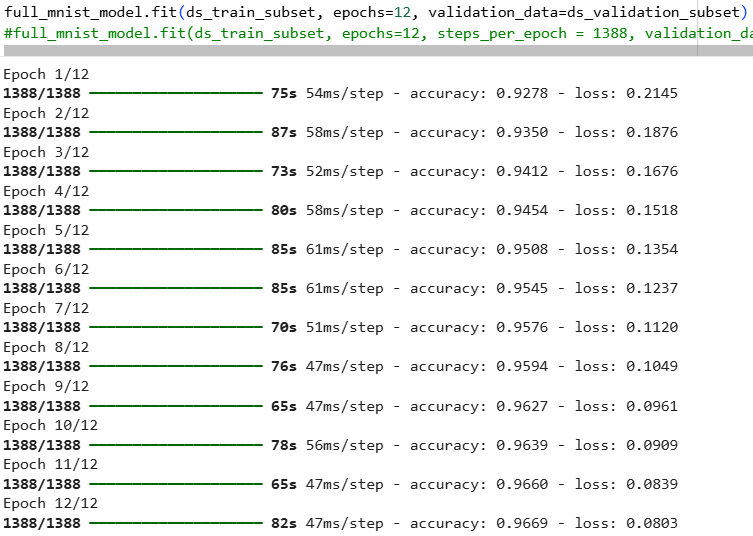

In [59]:
#Print the model summary to review the architecture and number of parameters
full_mnist_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 368,912 (1.41 MB)

 Trainable params: 122,970 (480.35 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 245,942 (960.71 KB)

Below is a screenshot of the model summary after the model did 10 epochs (the *first* time I ran the model).

 You can see the number of parameters for each layer of the model (the first time it was run), as well as the shape for each layer. The max pooling and flattening layers had 0 parameters and the first dense layer had the highest number of parameters, followed by the second convolutional layer, followed by (drastically lower) the last dense layer, followed by the first convolutional layer as the lowest number of parameters that wasn't 0.

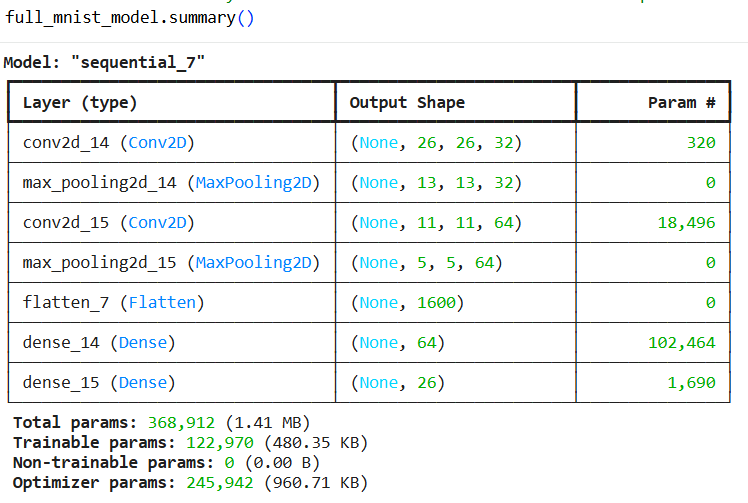

The *second* time I ran the model using 10 epochs, this was the model summary (see screenshot below). You can see that the layers, shapes, and number of parameters in each layer remained the same (as when the model was run the first time). These items did not change even though the model and epoch accuracies changed.



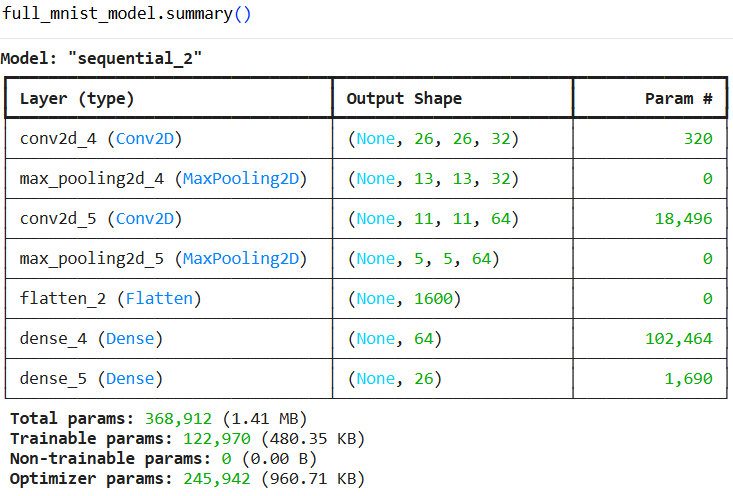

When running the model a third time, this time with 12 epochs, the model layers, shapes, and nubmer of parameters in each layer remained the same. (See screenshot below).

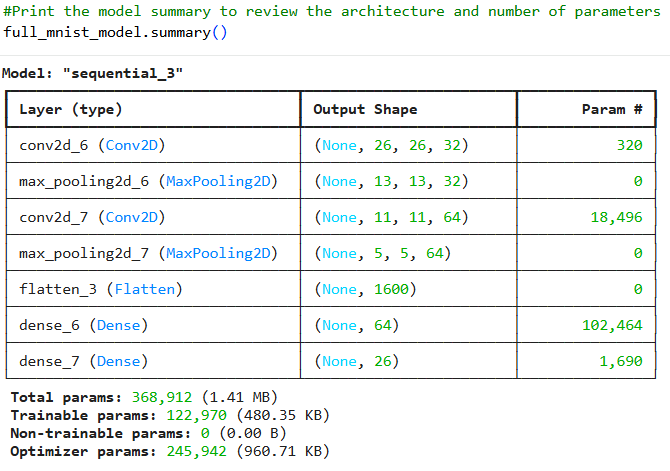

**4. Evaluation and Visualization**

**Tasks:**

1. Evaluate your trained model using the test set and report the test accuracy.

2. Display a few sample test images with their predicted class labels using Matplotlib.

3. Comment on your model’s performance and any observations.

1a. Evaluate trained model on test set.

I am looking to evaluate the model using the loss and accuracy from the test data.

In [60]:
#Evaluate the model on the test set
test_loss_f, test_acc_f = full_mnist_model.evaluate(ds_test, verbose=2)
print("Full MNIST Test Accuracy:", test_acc_f)

232/232 - 4s - 19ms/step - accuracy: 0.9136 - loss: 0.3299
Full MNIST Test Accuracy: 0.9136486649513245


1b. Report the test accuracy.

1) Here, the *first* time I ran the model, the model accuracy with test data (afte the model was trained and validated used training data) was 0.90959 which is **90.96%**, and it is **close to 91% accuracy** (when the model did 10 epochs). Below is a screenshot.



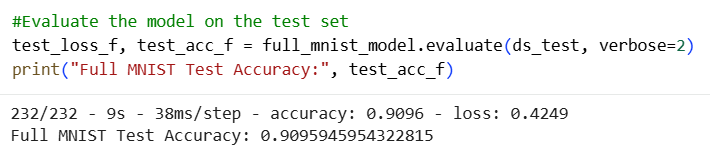

2) The *second* time I ran the model with 10 epochs, the model accuracy changes slightly. It increased to 0.9112 or **91.12%,** which is **still close to 91%** accuracy, but it's actually **slightly higher** (than 91%) than the first time the model was run (which was 90.96% accuracy).

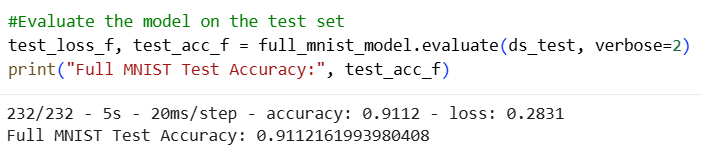

3) The *third* time I ran the model, this time with 12 epochs, the model accuracy changes more, and is slightly higher than either of the first two runs of the model with 10 epochs. It increased to 0.9136 or 91.36%, which is 40% higher than the first run of the model with 10 epochs, and 24% higher than the second run of the model with 10 epochs. It makes me wonder if I would get even higher accuracy if I ran the model with a greater number of epochs than 12.

There is a bigger difference between running the model with 10 epochs vs. 12 epochs (at least here, when I only ran the 10-epochs model twice and the 12-epochs model once), than the difference between each of the two runs of the model when they both had 10 epochs. Even though my number of time of running the model is limited, based on just this data it would make me want to run the 12-epoch model another time or two, then run a model with more than 12 epochs and see if the accuracy increases even more (for the total model accuracy).

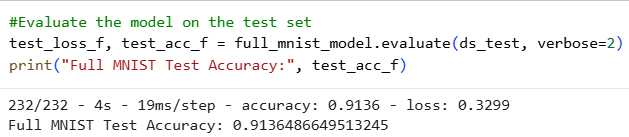

2. Display test images with predicted class labels.

First, find out how many test images are in the testing set.

In [61]:
#how many images are in the Test set
print(f"Testing set size: {ds_test.cardinality().numpy()}") #this was also initially working but now looks inaccurate because it's no longer displaying 14800.
#print(f"Type {type(ds_test)}")      #14,800 images in the Test set

#Two different WAYS to determine size of Test set

#1) determine size of test set from test set object
size_test = {ds_test.cardinality().numpy().item()}
print(f"size of TEST set: {size_test}")  #this way was working initially but now looks inaccurate as it's displaying 232.

#---------------------------------------------------------
#2) determine size of test set from the ds_info - USE THIS METHOD, it worked
TEST_SIZE = int(1 * ds_info.splits['test'].num_examples)
print(f"TEST set size: {TEST_SIZE}")    #14,800 images in the test set, verified a different way

Testing set size: 232
size of TEST set: {232}
TEST set size: 14800


**Next, work on taking a random sample image (from test data) and making a prediction.**

Make a prediction on a random sample image from the Full MNIST test set.

One issue came up when trying to do sample_image_f = ds_test[sample_index_f], it wasn't able to pull anything from ds_test using the square brackets and got an error. This is because the data type was different for the mnist digits data we practiced on in lecture vs the data now (the full letters mnist dataset). Tesnsorflow datasets give out something called a tuple which is a pair that has an image and a label (image, label). The code from the practice assignment with mnist digits a tuple to sample_image_f but it gets messed up when model.predict() is used because it gets a tuple instead of an image array. The model needs a single input tensor.

I made two changes. **First**, I made the ds_train data into a list (prior to doing the random sampling). Making it into a list stored it into memory in Python so it could be indexed before doing the random sample, but I read that this only works if the dataset is small enough (to be stored into memory). If it was a really, really large dataset, another method would have to be used if there wasn't enough memory.

**Second**, I then did sample_image_f, _ = ds_test_list[sample_index_f] (where there is a comma then a blank before the equals sign) to show that we don't care what the second part of the tuple is when doing the sample. The blank is placeholder for something that I'm not planning to use. But later I changed my mind and wanted to use it.

**Next**, I actually just changed the "_" (the blank) to sample_label because I decided I did want to see the label for the random sample.


In [69]:
# Make a prediction on a random sample image from the Full MNIST test set

# make sure numpy and tensorflow are imported and running
import numpy as nps
import tensorflow as tf

# TEST_SIZE is defined and ds_test is the dataset object
TEST_SIZE = 14800 # (from calculations above)

# Generate a random index for an INDIVIDUAL image within the full test set
sample_index_f = np.random.randint(0, TEST_SIZE)
print(f"type of sample_index_f: {type(sample_index_f)}")
print(f"sample_index_f: {sample_index_f}")

# To get the n-th individual element from a tf.data.Dataset:
# 1. unbatch the dataset to get individual (image, label) pairs
# 2. skip `sample_index_f` elements
# 3. take the next (and only) element
# Using `for ... in ...: break` is a common pattern to get the first (or only) element from a dataset iterator.
for sample_image_f, sample_label_f in ds_test.unbatch().skip(sample_index_f).take(1):
    break

# Now, sample_image_f and sample_label_f contain the chosen individual image and label.

# Expand dimensions to add a batch dimension for model prediction (model expects (batch_size, 28, 28, 1))
prediction_f = full_mnist_model.predict(tf.expand_dims(sample_image_f, axis=0))
predicted_class_f = np.argmax(prediction_f, axis=1)[0] # Get the single predicted class

print(f"Predicted class for Full MNIST sample: {predicted_class_f}")
print(f"Label for Full MNIST sample: {sample_label_f.numpy()}")

type of sample_index_f: <class 'int'>
sample_index_f: 7415
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted class for Full MNIST sample: 10
Label for Full MNIST sample: 10


**Display the sample image**.

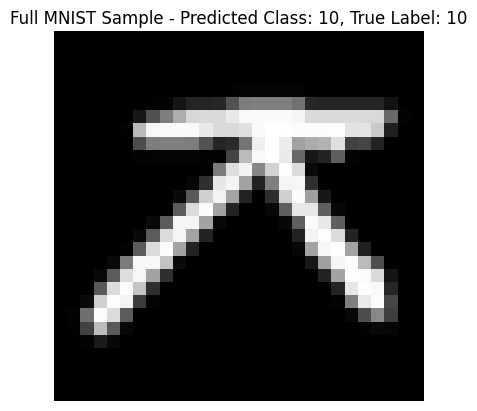

In [70]:
# Display the sample image with predicted class
# Ensure numpy behavior is enabled for direct tensor to numpy conversion
tf.experimental.numpy.experimental_enable_numpy_behavior()

# Convert the TensorFlow tensor to a NumPy array for matplotlib and reshape to 2D
plt.imshow(sample_image_f.numpy().reshape(28,28), cmap='gray')
plt.title("Full MNIST Sample - Predicted Class: {}, True Label: {}".format(predicted_class_f, sample_label_f.numpy()))
plt.axis('off')
plt.show()

The first time I ran the model, then did a random sample of the test data and made a prediction, this is the image a got (see screenshot below). It's a letter "d". The first time around, I forgot to have the image display both the predicted class and the true label, but on the next several images, it shows the predicted class and true label. For this image, the prediction had predicted class 3 but said the true label was class 4 (although it wasn't printed on the displayed image).

Online I researched which class goes with which letter, and it said that A is 1, but is class 2, C is class 3, E is class 4, ..., and Z is class 26, but I don't know if that is accurate. It appears that at least with my predicted and labeled images, they seem like they are off a class by one. (AT least my understanding of which class matches up with which letter).

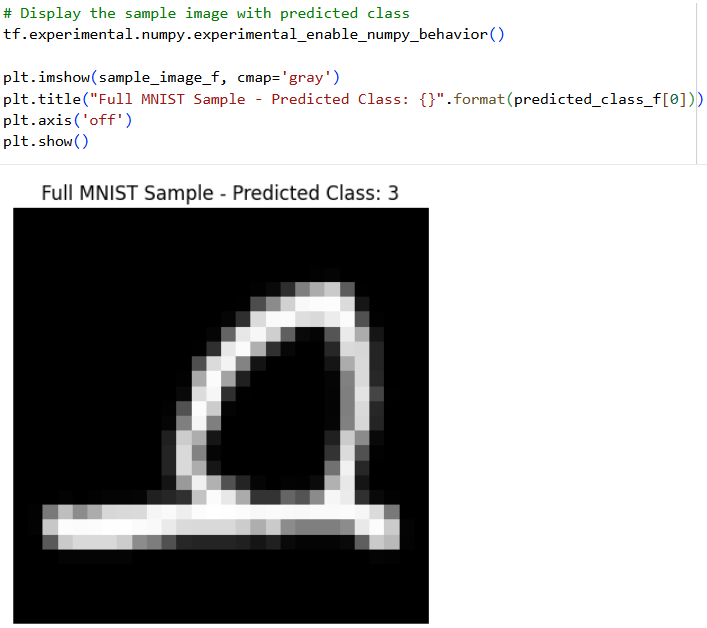

The second time I drew a random sample test image and did a prediction, I got a "Q", and it predicted the class as the same as the true label. See image screenshot below. It predicted class 16 and said the true label was class 16, which I thought would be a "P" but it looks like a "Q".

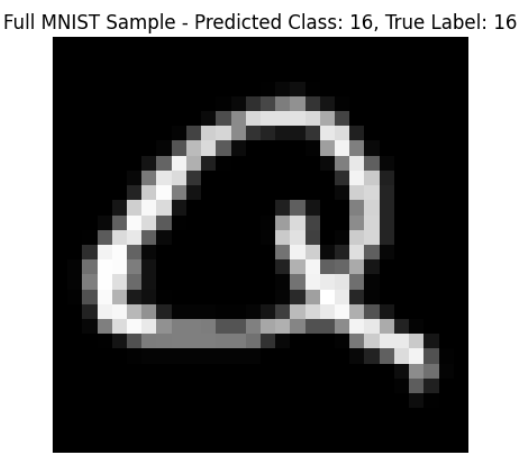

When I ran the model a third time and used 12 epochs (instead of 10), then did a random sampling of the test data to make a prediction and then display the image, I got that it predicted class 10 and the true label was class 10. I thought class 10 would be a "J" but it looks like a "K". (see screenshot below).

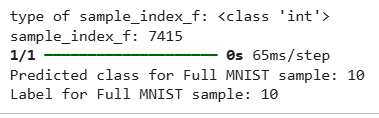

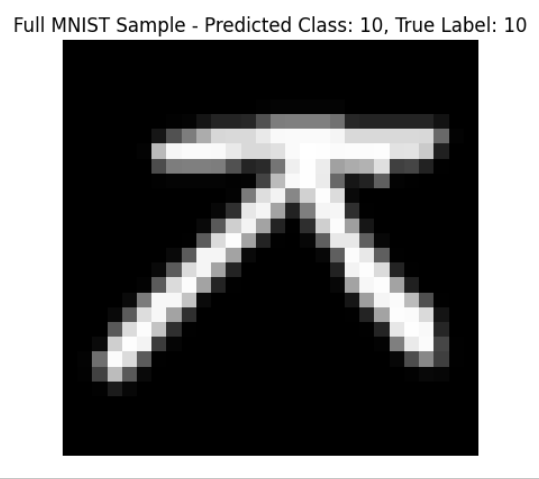

3. Comment on my model's performance (and any observations).

**Please see observations throughout the notebook document, by each section.** I tried to insert observations and explanations throughout each section of the project, so all my comments are not necessarily here at the bottom of the document, but some are spread within. Thank you.

 **One big takeaway** was that the number of batches and steps_per_epoch matter, including the number of images in the training dataset. Also, the accuracies of the epochs changed slightly each time I ran the model using the same number of epochs (in this case, epochs = 10). The total model accuracies varied very slightly even though there was greater variation in the epochs from first to last, so it seemed like even though there was variation in the accuracy of epochs each time I ran the model, it didn't seem like it impacted the total model accuracy when the model accuracy was evaluated. For example, the first time I ran the model with 10 epochs, the model accuracy was 90.96% and the second time the model accuracy was 91.12%.  The difference in accuracies between running the model the first time and running the model the second time (with the same number of 10 epochs) was a difference of 0.16%.

I could try to run a statistical test to see if the two accuracies are statistically significantly different or not. I'm guessing, without running a statistical test, that they may not be statitistically significantly different. That is key, because it means that the model is pretty good in terms of the number of epochs, because each time the model is run it is resulting in a very close accuracy to the other times it is run. Hopefully this model is not overfit. Though there is variation in the epochs accuracy across running the models more than once, the total model accuracy is almost identitcal.

 I would like to run the model 10 times, look at the variation in accuracies for the epochs, then look to see what the differneces are in total model accuracy and run an ANOVA to see if any of them are statistically different. I don't know if that's the best way to see how good this model is but it might be interesting. I'm guessing based on runnning the model twice, that there may not be a lot of differences in total model accuracy after running it 8 more times, even accounting for the randomness from the adam optimization algorithm and assigning the weights.

**COMMENTS:**

(*NOTE: *Please see comments throughout the project, in different sections, before the code chunks. I made comments as I went and tried to describe what I was observing and what I thought was going on and why*).

The sample images outputted each time I run a random sample, make a prediction, then display the image of the sample image - sometimes they appear rotated 90 degrees and inverted or reflected (like a mirror opposite). Online some people commented that they needed to do some operations to rotate and reflect the images so the display image appears to look like the proper orientation of the letter.

Although interestingly, some of the letters, like the "Q" the second time I ran the model with 10 epochs, looks like a "Q" in its proper orientation. So maybe only some of the letters needs to be rotated and/or inverted.

**5. Documentation and Submission**

**1. Documentation:** Ensure that your Colab notebook is well-documented. Include comments in each code cell explaining what each section of code is doing.


**2. File Submission:** When you have completed the assignment, save your Google Colab notebook as a .ipynb file and upload it to Brightspace as your assignment submission. (Example SmithMod02.ipynb)